# 1.支持向量机 Support Vector Machine

- 解决的问题：什么样的决策边界最好
- 特征数据本身就很难分怎么办
- 计算复杂度如何，能否实际应用


## 1.1 SVM原理

### 1.1.1如何选择决策边界
选出离雷区最远的（雷区就是边界上的点），需要一个更大的决策边界

**数据标签定义**：
- Y为样本的类别，X为正例 Y = +1
- 决策方程：$y(x) = w^T\Phi(x)+b$ 其中$\Phi(x)$是对数据做了变换
  - $y(x_i) > 0$ 则 $y_i = +1$
  - $y(x_i) > 0$ 则 $y_i = +1$



### 1.1.2优化目标：
找到一条线（由w和b和构成），使得离该线最近的点能够最远
- 点到直线距离简化得到

$$\frac{y_i * (w^T\Phi(x_i)+b)}{\|\mathbf{w}\|}$$

- 放缩变换：对决策方程（w,b），可以通过放缩使得结果|Y| >= 1，即$y_i * (w^T\Phi(x_i)+b) >= 1 $
- 优化目标：
$$\arg\max_{\mathbf{w}, b} \left\{ \min_{i} \left[ y_i \frac{\mathbf{w}^T \phi(\mathbf{x}_i) + b}{\|\mathbf{w}\|} \right] \right\}$$

    - 由于$y_i * (w^T\Phi(x_i)+b) >= 1 $,只需要考虑$\arg\max \frac{1}{\|\mathbf{w}\|}$
- 最大化几何间隔 $\gamma = \frac{1}{\|\mathbf{w}\|}$，等价于最小化：$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2$; 1/2是常数项，不重要
- 约束条件：$y_i (\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \quad \forall i=1,\dots,n$



### 1.1.3 如何求解：拉格朗日乘子法

- 拉格朗日函数：
    $$
    L(\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2} \|\mathbf{w}\|^2 - \sum_{i=1}^n \alpha_i [y_i (\mathbf{w}^T \mathbf{x}_i + b) - 1]
    $$
  - 其中 $\alpha_i \geq 0$ 是拉格朗日乘子。

- 对 $\mathbf{w}$ 和 $b$ 求偏导并置零：
    $$
    \begin{aligned}
    \nabla_{\mathbf{w}} L &= \mathbf{w} - \sum_{i=1}^n \alpha_i y_i \mathbf{x}_i = 0 \\
    \frac{\partial L}{\partial b} &= -\sum_{i=1}^n \alpha_i y_i = 0
    \end{aligned}
    $$

- 代入后得到**对偶问题**：
    $$
    \max_{\boldsymbol{\alpha}} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j \mathbf{x}_i^T \mathbf{x}_j
    $$
    - 约束条件：
    $$
    \sum_{i=1}^n \alpha_i y_i = 0, \quad \alpha_i \geq 0 \quad \forall i
    $$
- 极大值转化成极小值问题
    $$
    \min_{\boldsymbol{\alpha}} \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j \mathbf{x}_i^T \mathbf{x}_j - \sum_{i=1}^n \alpha_i
    $$

- KKT 条件（最优解满足）
    1. $\alpha_i \geq 0$
    2. $y_i f(\mathbf{x}_i) - 1 \geq 0$
    3. $\alpha_i [y_i f(\mathbf{x}_i) - 1] = 0$


- 所有$\alpha$值不为0的点，称为支撑向量
- 支持向量中，真正发挥作用的数据点是$\alpha$值不为0的点

### 1.1.4 softmargin

- 软间隔：有时候数据中包含噪音点，不应该考虑异常点
- 要求$y_i f(\mathbf{x}_i) \geq 1$过于严格
- 引入松弛因子：$y_i f(\mathbf{x}_i) \geq 1-\xi_i$


- 引入松弛变量 $\xi_i$ 和惩罚参数 $C$的新目标函数：
    $$
    \min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i
    $$
    - 约束条件：
    $$
    \begin{cases}
    y_i (\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i \\
    \xi_i \geq 0 \quad \forall i
    \end{cases}
    $$
    - 当C很大是，意味严格分类不能有错误
    - 当C很小时，意味着有更大的错误容忍
    - C是需要制定的参数


### 1.1.5 核变换
为了解决低维不可分问题，就是找到一种变换方法 $\phi(x)$，使它映射到高维空间

- 核变换:高维映射
- 引入核函数 $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$ 代替内积：
$$
\max_{\boldsymbol{\alpha}} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j} \alpha_i \alpha_j y_i y_j K(\mathbf{x}_i, \mathbf{x}_j)
$$
- 可以先在低维空间计算内积，再把内积的结果映射到高维空间（降低计算复杂度）

**常用核函数**
主要用RBF核（高斯核函数）

| 核函数类型 | 表达式 |
|------------|--------|
| 线性核 | $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$ |
| 多项式核 | $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i^T \mathbf{x}_j + r)^d$ |
| RBF 核 | $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$ |
| Sigmoid 核 | $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma \mathbf{x}_i^T \mathbf{x}_j + r)$ |

## 1.2SVM模拟

In [2]:
import numpy as np
import os
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris()
X = iris['data'][:,(2,3)]
y = iris['target']

yon = (y==0)|(y==1)
X = X[yon]
y = y[yon]

svm = SVC(kernel='linear',C=float('inf'))
svm.fit(X,y)

SVC(C=inf, kernel='linear')

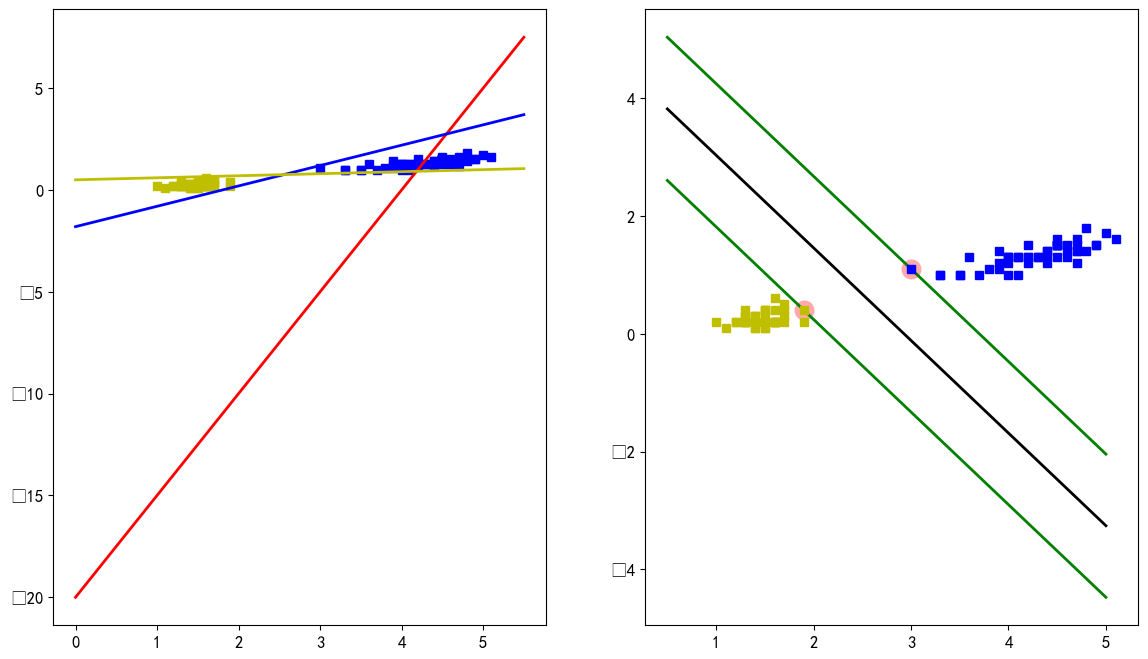

In [6]:
x0 = np.linspace(0,5.5,200)
pred_1 = 5*x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1*x0 + 0.5

def plot_svm(svm,xmin,xmax,sv=True):
    w = svm.coef_[0]
    b = svm.intercept_[0]
    x0 = np.linspace(xmin,xmax,200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    if sv:
        svs = svm.support_vectors_
        plt.scatter(svs[:,0],svs[:,1],s=180,facecolors='#FFAAAA')
    plt.plot(x0,decision_boundary,'k-',linewidth=2)
    plt.plot(x0,gutter_up,'g-',linewidth=2)
    plt.plot(x0,gutter_down,'g-',linewidth=2)
plt.figure(figsize=(14,8))
plt.subplot(121)
plt.plot(X[:,0][y==1],X[:,1][y==1],'bs',linewidth=2)
plt.plot(X[:,0][y==0],X[:,1][y==0],'ys',linewidth=2)
plt.plot(x0,pred_1,'r-',linewidth=2)
plt.plot(x0,pred_2,'b-',linewidth=2)
plt.plot(x0,pred_3,'y-',linewidth=2)
plt.subplot(122)
plot_svm(svm,0.5,5)
plt.plot(X[:,0][y==1],X[:,1][y==1],'bs',linewidth=2)
plt.plot(X[:,0][y==0],X[:,1][y==0],'ys',linewidth=2)

In [10]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()
X = iris['data'][:,(2,3)]
y = iris['target']
svm = Pipeline((
    ('scaler', StandardScaler()),
    ('linear_svc', LinearSVC(C=1)),
))
svm.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()), ('linear_svc', LinearSVC(C=1))])

In [9]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

不同C带来效果不同

In [11]:
svm.predict([[1,2]])

array([0])

In [13]:
scaler = StandardScaler()
svm1 = LinearSVC(C=1,random_state=42)
svm2 = LinearSVC(C=100,random_state=42)
scaled_svm1 = Pipeline((
    ('scaler', StandardScaler()),
    ('linear_svc',svm1 ),
))
scaled_svm2 = Pipeline((
    ('scaler', StandardScaler()),
    ('linear_svc', svm2),
))
scaled_svm2.fit(X,y)
scaled_svm1.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, random_state=42))])

In [14]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_svm = Pipeline((
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('linear_svc', LinearSVC(C=1,loss='hinge',random_state=42)),
))
polynomial_svm.fit(X,y)

Pipeline(steps=[('poly', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

In [ ]:
def plot_prediction(clf,axes):
    x0s = np.linspace(axes[0],axes[1],100)
    x1s = np.linspace(axes[2],axes[3],100)
    x0,x1 = np.meshgrid(x0s,x1s)
    X = np.c_[x0.ravel(),x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0,x1,y_pred,cmap=plt.cm.Paired)
plot_prediction(polynomial_svm,[-1.5,2.5,-1,1.5])
